# Data block tutorial
https://docs.fast.ai/tutorial.datablock.html

## Building a DataBlock from scratch

The rest of this tutorial will give many examples, but let’s first build a DataBlock from scratch on the dogs versus cats problem we saw in the vision tutorial. First we import everything needed in vision.

In [1]:
from fastai.data.all import * # the fastai library for computer vision
from fastai.vision.all import *

In [2]:
#download and decompress the Oxford-IIIT Pet Dataset that contains images of cats and dogs of 37 different breeds
#URLs.PETS is built into the fastai module
path = untar_data(URLs.PETS)

It will only do this download once, and return the location of the decompressed archive. We can check what is inside with the .ls() method.

In [3]:
path.ls()

(#2) [Path('C:/Users/hilton.netta/.fastai/data/oxford-iiit-pet/annotations'),Path('C:/Users/hilton.netta/.fastai/data/oxford-iiit-pet/images')]

We will ignore the annotations folder for now, and focus on the images one. get_image_files is a fastai function that helps us grab all the image files (recursively) in one folder.

In [9]:
files = get_image_files(path/"images")
#files = get_image_files(path/"annotations")
len(files)

7390

And as we saw, all the filenames are in the “images” folder. The get_image_files function helps get all the images in subfolders:

In [4]:
fnames = get_image_files(path/"images")

Let’s begin with an empty DataBlock.

## Cats vs dogs
To label our data for the cats vs dogs problem, we need to know which filenames are of dog pictures and which ones are of cat pictures. There is an easy way to distinguish: the name of the file begins with a capital for cats, and a lowercased letter for dogs:

In [10]:
files[0],files[6]

(Path('C:/Users/hilton.netta/.fastai/data/oxford-iiit-pet/images/Abyssinian_1.jpg'),
 Path('C:/Users/hilton.netta/.fastai/data/oxford-iiit-pet/images/Abyssinian_104.jpg'))

We can then define an easy label function:

In [11]:
def label_func(f): return f[0].isupper()

To get our data ready for a model, we need to put it in a DataLoaders object. Here we have a function that labels using the file names, so we will use ImageDataLoaders.from_name_func. There are other factory methods of ImageDataLoaders that could be more suitable for your problem, so make sure to check them all in vision.data.

In [14]:
dls = ImageDataLoaders.from_name_func(path, files, label_func, item_tfms=Resize(224))

We have passed to this function the directory we’re working in, the files we grabbed, our label_func and one last piece as item_tfms: this is a Transform applied on all items of our dataset that will resize each image to 224 by 224, by using a random crop on the largest dimension to make it a square, then resizing to 224 by 224. If we didn’t pass this, we would get an error later as it would be impossible to batch the items together.

We can then check if everything looks okay with the show_batch method (True is for cat, False is for dog):

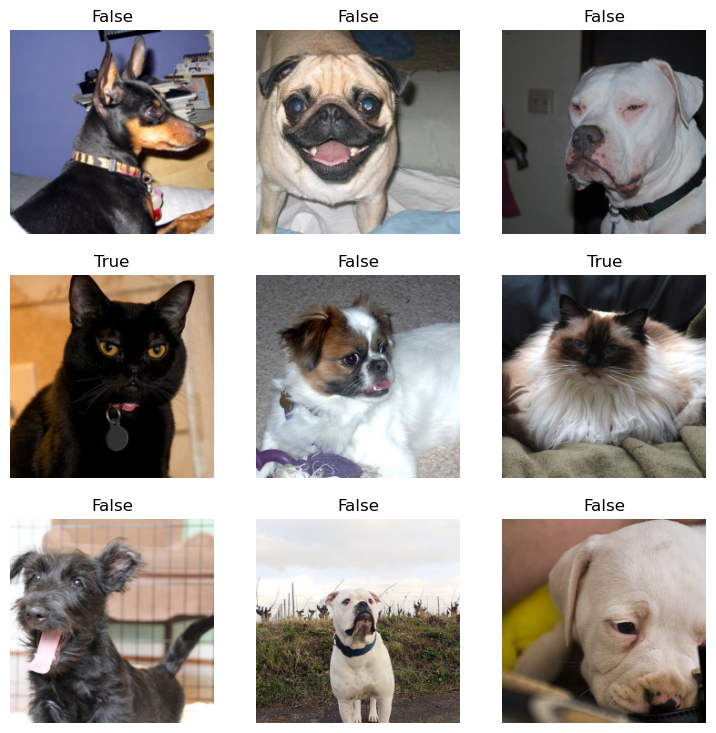

In [15]:
dls.show_batch()

Then we can create a Learner, which is a fastai object that combines the data and a model for training, and uses transfer learning to fine tune a pretrained model in just two lines of code:

In [16]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to C:\Users\hilton.netta/.cache\torch\hub\checkpoints\resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:11<00:00, 7.73MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.145334,0.023074,0.007442,11:16


epoch,train_loss,valid_loss,error_rate,time
0,0.060628,0.027189,0.008119,14:44


The first line downloaded a model called ResNet34, pretrained on ImageNet, and adapted it to our specific problem. It then fine tuned that model and in a relatively short time, we get a model with an error rate of well under 1%… amazing!

If you want to make a prediction on a new image, you can use learn.predict:

In [17]:
learn.predict(files[0])

('True', tensor(1), tensor([2.1323e-05, 9.9998e-01]))

The predict method returns three things: the decoded prediction (here True for cat), the index of the predicted class and the tensor of probabilities of all classes in the order of their indexed labels(in this case, the model is quite confident about the being that of a dog). This method accepts a filename, a PIL image or a tensor directly in this case. We can also have a look at some predictions with the show_results method:

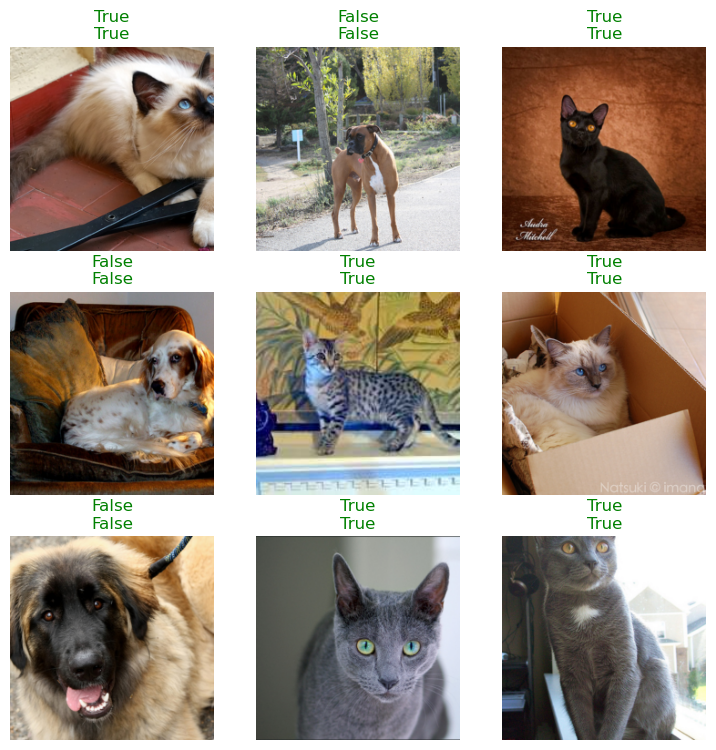

In [18]:
learn.show_results()

## Classifying breeds
To label our data with the breed name, we will use a regular expression to extract it from the filename. Looking back at a filename, we have:

In [19]:
files[0].name

'Abyssinian_1.jpg'

so the class is everything before the last _ followed by some digits. A regular expression that will catch the name is thus:

In [21]:
pat = r'^(.*)_\d+.jpg'

Since it’s pretty common to use regular expressions to label the data (often, labels are hidden in the file names), there is a factory method to do just that:

In [22]:
dls = ImageDataLoaders.from_name_re(path, files, pat, item_tfms=Resize(224))

Like before, we can then use show_batch to have a look at our data:

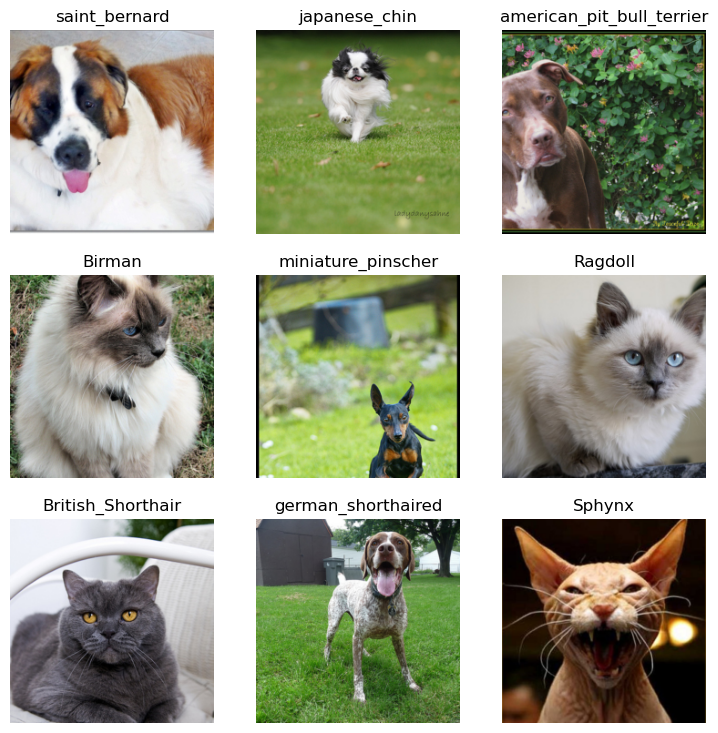

In [23]:
dls.show_batch()

Since classifying the exact breed of cats or dogs amongst 37 different breeds is a harder problem, we will slightly change the definition of our DataLoaders to use data augmentation:

In [24]:
dls = ImageDataLoaders.from_name_re(path, files, pat, item_tfms=Resize(460),
                                    batch_tfms=aug_transforms(size=224))

We can then create our Learner exactly as before and train our model.

In [26]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn

We used the default learning rate before, but we might want to find the best one possible. For this, we can use the learning rate finder:

SuggestedLRs(valley=0.0010000000474974513)

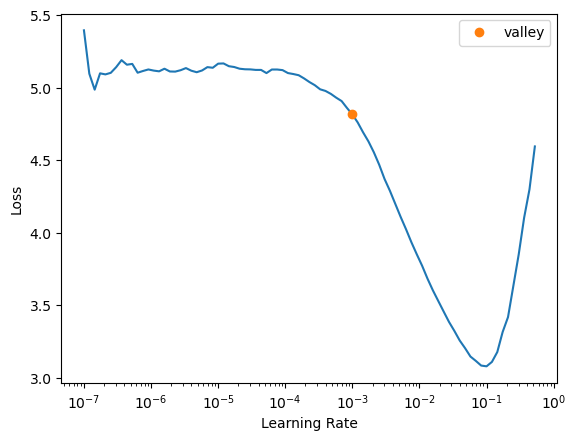

In [27]:
learn.lr_find()

It plots the graph of the learning rate finder and gives us two suggestions (minimum divided by 10 and steepest gradient). Let’s use 3e-3 here. We will also do a bit more epochs:

In [28]:
learn.fine_tune(2, 3e-3)

epoch,train_loss,valid_loss,error_rate,time
0,1.283823,0.331222,0.104871,15:37


epoch,train_loss,valid_loss,error_rate,time
0,0.523615,0.356430,0.110961,22:24
1,0.319752,0.220117,0.070365,21:56


Again, we can have a look at some predictions with show_results:

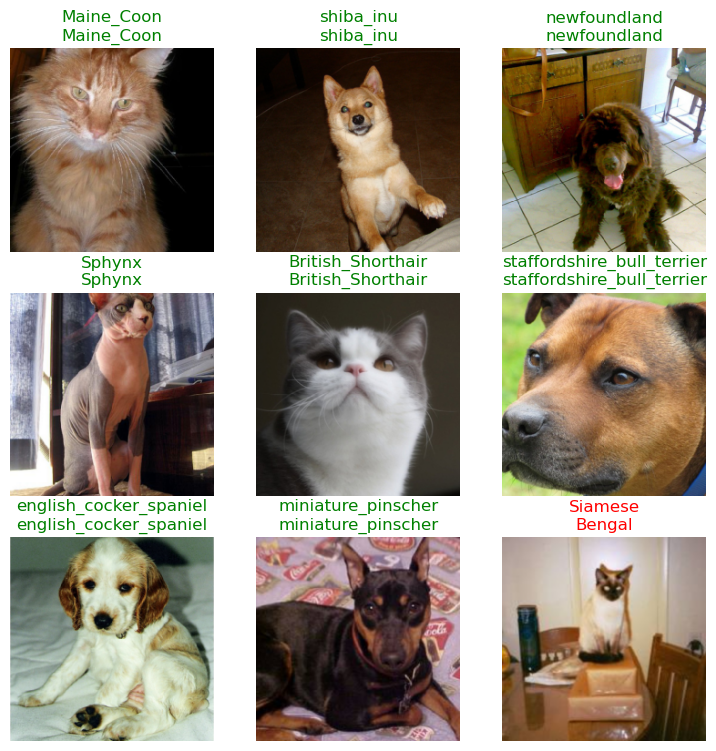

In [29]:
learn.show_results()

Another thing that is useful is an interpretation object, it can show us where the model made the worse predictions:

In [30]:
interp = Interpretation.from_learner(learn)

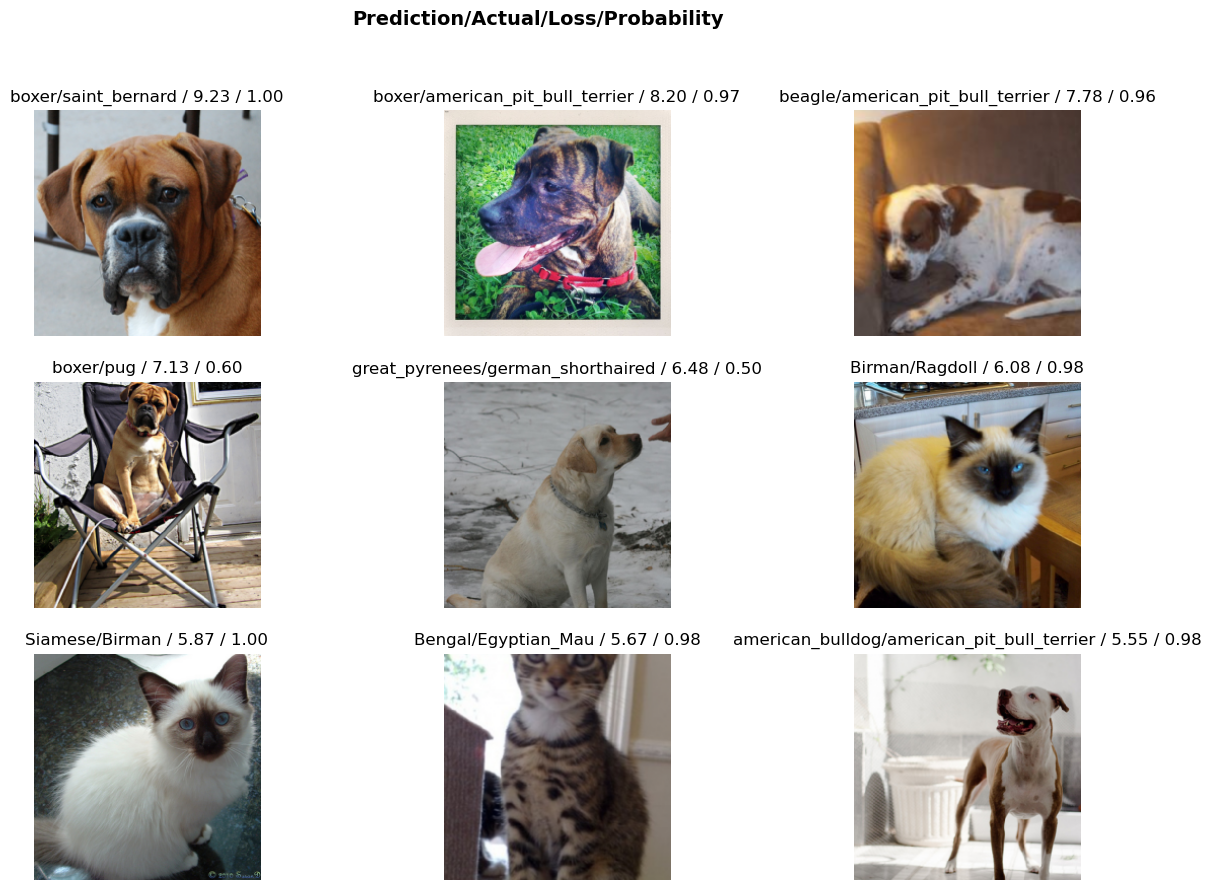

In [31]:
interp.plot_top_losses(9, figsize=(15,10))

In [5]:
dblock = DataBlock()

By itself, a DataBlock is just a blue print on how to assemble your data. It does not do anything until you pass it a source. You can choose to then convert that source into a Datasets or a DataLoaders by using the DataBlock.datasets or DataBlock.dataloaders method. Since we haven’t done anything to get our data ready for batches, the dataloaders method will fail here, but we can have a look at how it gets converted in Datasets. This is where we pass the source of our data, here all our filenames:

In [6]:
dsets = dblock.datasets(fnames)
dsets.train[0]

(Path('C:/Users/hilton.netta/.fastai/data/oxford-iiit-pet/images/chihuahua_30.jpg'),
 Path('C:/Users/hilton.netta/.fastai/data/oxford-iiit-pet/images/chihuahua_30.jpg'))

By default, the data block API assumes we have an input and a target, which is why we see our filename repeated twice.

The first thing we can do is use a get_items function to actually assemble our items inside the data block:

In [6]:
dblock = DataBlock(get_items = get_image_files)